In [63]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
df1=pd.read_csv("../Data/resumeJD_with_domains.csv")
df2=pd.read_csv("../Data/resumeJD_with_education.csv")
df3=pd.read_csv("../Data/resumeJD_with_experience.csv")
df4=pd.read_csv("../Data/resumeJD_with_semantic_similarity.csv")
df5=pd.read_csv("../Data/skill_extracted_resumeJD.csv")

print(df1.head())
print()
print(df2.head())
print()
print(df3.head())
print()
print(df4.head())
print()
print(df5.head())

                                         resume_text  \
0  name kritika shah email phone linkedin locatio...   
1  name arjun verma email phone linkedin location...   
2  name manish bhatt email phone linkedin locatio...   
3  name natasha sharma email phone linkedin locat...   
4  name kavya agarwal email phone linkedin locati...   

                                     job_description  match_score  \
0  job title fp a analyst company amazon location...         0.55   
1  job title design lead company paytm location c...         0.27   
2  job title security analyst company kpmg locati...         0.46   
3  job title sales director company ola location ...         0.09   
4  job title business development manager company...         0.66   

     match_label                                      resume_skills  \
0  partial match  ['ca', 'cfa', 'equity research', 'forecasting'...   
1       no match  ['a b testing', 'forecasting', 'google analyti...   
2  partial match  ['communication',

In [65]:
df1.info()
df2.info()
df3.info()
df4.info()
df5.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   resume_text                500 non-null    str    
 1   job_description            500 non-null    str    
 2   match_score                500 non-null    float64
 3   match_label                500 non-null    str    
 4   resume_skills              500 non-null    str    
 5   jd_skills                  500 non-null    str    
 6   matched_skills             500 non-null    str    
 7   missing_skills             500 non-null    str    
 8   skill_match_score          500 non-null    float64
 9   matched_skill_count        500 non-null    int64  
 10  missing_skill_count        500 non-null    int64  
 11  resume_experience          500 non-null    int64  
 12  jd_experience              500 non-null    int64  
 13  experience_match_score     500 non-null    float64
 14  resum

In [66]:
df1=df1.rename(columns={'match_score':'final_score'})
print(df1.columns)
print(df1['final_score'].head())
print(df1['match_label'].head())
print(df1['skill_match_score'].head())
print(df1['experience_match_score'].head())
print(df1['semantic_similarity_score'].head())
print(df1['domain_match'].head())


Index(['resume_text', 'job_description', 'final_score', 'match_label',
       'resume_skills', 'jd_skills', 'matched_skills', 'missing_skills',
       'skill_match_score', 'matched_skill_count', 'missing_skill_count',
       'resume_experience', 'jd_experience', 'experience_match_score',
       'resume_education', 'resume_education_level',
       'semantic_similarity_score', 'resume_domain', 'jd_domain',
       'domain_match'],
      dtype='str')
0    0.55
1    0.27
2    0.46
3    0.09
4    0.66
Name: final_score, dtype: float64
0    partial match
1         no match
2    partial match
3         no match
4    partial match
Name: match_label, dtype: str
0    0.17
1    0.00
2    0.00
3    0.00
4    0.00
Name: skill_match_score, dtype: float64
0    0.62
1    1.00
2    1.00
3    1.00
4    1.00
Name: experience_match_score, dtype: float64
0    0.5825
1    0.6030
2    0.4904
3    0.4277
4    0.5142
Name: semantic_similarity_score, dtype: float64
0    1
1    0
2    0
3    0
4    0
Name: domain

TARGET VARIABLE DEEPDIVE & FEATURE WISE SPLIT

match_label
no match         190
match            158
partial match    152
Name: count, dtype: int64
               count      mean       std   min   25%    50%     75%   max
match_label                                                              
match          158.0  0.860570  0.070143  0.75  0.80  0.860  0.9275  0.98
no match       190.0  0.220000  0.103305  0.05  0.13  0.215  0.3100  0.39
partial match  152.0  0.572961  0.103558  0.40  0.48  0.580  0.6700  0.74
               count      mean       std  min   25%   50%   75%  max
match_label                                                         
match          158.0  0.392405  0.203265  0.0  0.25  0.40  0.50  1.0
no match       190.0  0.044368  0.097863  0.0  0.00  0.00  0.00  0.5
partial match  152.0  0.165855  0.201900  0.0  0.00  0.11  0.25  1.0
               count      mean       std   min     25%  50%  75%  max
match_label                                                          
match          158.0  0.874051  0.216939  0.

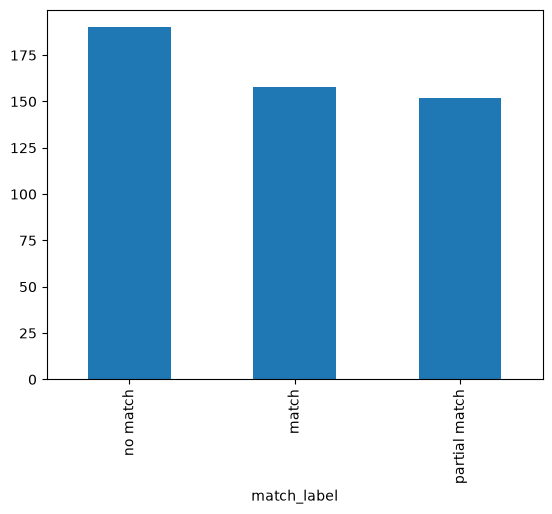

In [67]:
print(df1['match_label'].value_counts())
df1['match_label'].value_counts().plot(kind='bar')
print(df1.groupby("match_label")["final_score"].describe())
print(df1.groupby("match_label")["skill_match_score"].describe())
print(df1.groupby("match_label")["experience_match_score"].describe())
print(df1.groupby("match_label")["semantic_similarity_score"].describe())
print(df1.groupby("match_label")["domain_match"].describe())

CORRELATION ANALYSIS

skill_match_score            0.581308
experience_match_score      -0.027246
semantic_similarity_score    0.622378
domain_match                 0.475254
final_score                  1.000000
Name: final_score, dtype: float64
<StringArray>
['partial match', 'no match', 'match']
Length: 3, dtype: str
skill_match_score            0.641302
experience_match_score      -0.028654
semantic_similarity_score    0.646216
domain_match                 0.531293
final_score                  0.942106
num_match_label              1.000000
Name: num_match_label, dtype: float64


<Axes: >

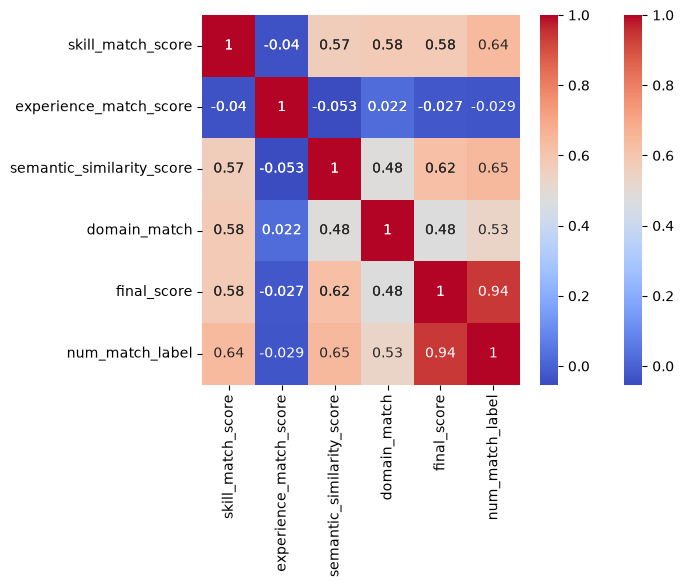

In [68]:
cols=['skill_match_score','experience_match_score','semantic_similarity_score','domain_match','final_score']
print(df1[cols].corr()['final_score'])
sns.heatmap(df1[cols].corr(), annot=True, cmap='coolwarm')
print(df1['match_label'].unique())
df1['num_match_label']=df1['match_label'].replace(['partial match', 'no match', 'match'], [0.5, 0, 1])
cols2 = ['skill_match_score','experience_match_score','semantic_similarity_score','domain_match','final_score','num_match_label']
print(df1[cols2].corr()['num_match_label'])
sns.heatmap(df1[cols2].corr(), annot=True, cmap='coolwarm')

In [69]:
dm=df1[['skill_match_score','experience_match_score','semantic_similarity_score','domain_match','final_score',"match_label","num_match_label"]]
dm=dm.rename(columns={'Unnamed: 0':'idx'})
print(dm.head())
print(dm.columns)
dm.to_csv("../Data/datamain.csv",index=False)

   skill_match_score  experience_match_score  semantic_similarity_score  \
0               0.17                    0.62                     0.5825   
1               0.00                    1.00                     0.6030   
2               0.00                    1.00                     0.4904   
3               0.00                    1.00                     0.4277   
4               0.00                    1.00                     0.5142   

   domain_match  final_score    match_label num_match_label  
0             1         0.55  partial match             0.5  
1             0         0.27       no match               0  
2             0         0.46  partial match             0.5  
3             0         0.09       no match               0  
4             0         0.66  partial match             0.5  
Index(['skill_match_score', 'experience_match_score',
       'semantic_similarity_score', 'domain_match', 'final_score',
       'match_label', 'num_match_label'],
      dtype='s